In [2]:
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import BaseMessage, HumanMessage
from typing import TypedDict, Annotated
from langchain_groq import ChatGroq
from langgraph.graph.message import add_messages
from dotenv import load_dotenv
from langgraph.checkpoint.memory import MemorySaver

In [3]:
class ChatState(TypedDict):
    # BaseMessage means any tpe of message can exit in this list like it could be human, AI,system message
    # addmessages work same as operator.add but it is more optimized with baseMessage
    messages: Annotated[list[BaseMessage], add_messages]

In [4]:
load_dotenv()
llm = ChatGroq(model="openai/gpt-oss-120b")
def chat_node(state: ChatState):

    # take user input
    messages = state['messages']

    # send to llm
    response = llm.invoke(messages)

    # return state
    return {'messages': [response]}


In [5]:
checkpointer = MemorySaver()
graph = StateGraph(ChatState)

graph.add_node('chat_node', chat_node)

graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)

chatbot = graph.compile(checkpointer=checkpointer)


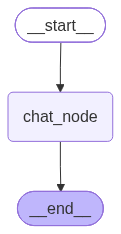

In [6]:
chatbot

In [8]:
initial_state = {
    'messages': [HumanMessage(content='What is the previous and current capital of Pakistan')]}

#answer = chatbot.invoke(initial_state)
#answer

In [ ]:
# only get AI message(response)
#answer['messages'][-1]

AIMessage(content='Pakistan’s capital has changed once since the country’s independence:\n\n| Period | Capital city |\n|--------|--------------|\n| **1947\u202f–\u202f1963** | **Karachi** – the largest city and main port, it served as the capital from independence until the early 1960s. |\n| **1963\u202f–\u202fpresent** | **Islamabad** – a purpose‑built city in the north‑west of the country, officially inaugurated as the capital in 1963. |\n\nSo, the **previous capital** was **Karachi**, and the **current capital** is **Islamabad**.', additional_kwargs={'reasoning_content': 'The user asks: "What is the previous and current capital of Pakistan". They want factual info. This is allowed. Provide answer: previous capital was Karachi (until 1963), current is Islamabad (since 1963). Also mention that before independence, capital of British India was Delhi, but for Pakistan it\'s Karachi then Islamabad. Provide concise answer.'}, response_metadata={'token_usage': {'completion_tokens': 207, 'p

In [ ]:
# if only want content of answer
#answer['messages'][-1].content

'Pakistan’s capital has changed once since the country’s independence:\n\n| Period | Capital city |\n|--------|--------------|\n| **1947\u202f–\u202f1963** | **Karachi** – the largest city and main port, it served as the capital from independence until the early 1960s. |\n| **1963\u202f–\u202fpresent** | **Islamabad** – a purpose‑built city in the north‑west of the country, officially inaugurated as the capital in 1963. |\n\nSo, the **previous capital** was **Karachi**, and the **current capital** is **Islamabad**.'

In [11]:
thread_id = '1'

while True:

    user_msg = input('Type here: ')
    print('User: ', user_msg)

    if user_msg.strip().lower() in ['exit', 'quit', 'bye']:
        break

    config = {'configurable': {'thread_id': thread_id}}
    response = chatbot.invoke({'messages': [HumanMessage(content= user_msg)]}, config= config)
    print('AI: ', response['messages'][-1].content)

    # the flaw in this code is that everytime we invode or ask new message the state starts from scratch 
    # and our model don't know what we said before means no memory
    # now we add new concept if langgraph which is persistence

User:  what is my name
AI:  Your name is Esha.
User:  how can i assist you?
AI:  I appreciate the offer, Esha! I don’t need any help myself, but I’m here to assist you. Let me know if there’s anything you’d like to discuss, learn about, or get help with. 😊
User:  bye


In [12]:
chatbot.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='hello', additional_kwargs={}, response_metadata={}, id='bde26e5f-be84-4915-ad91-2b05ad3ded19'), AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'reasoning_content': 'The user says "hello". The system says we need to follow the guidelines. It\'s a simple greeting. We respond politely.'}, response_metadata={'token_usage': {'completion_tokens': 44, 'prompt_tokens': 72, 'total_tokens': 116, 'completion_time': 0.091676453, 'completion_tokens_details': {'reasoning_tokens': 26}, 'prompt_time': 0.002811654, 'prompt_tokens_details': None, 'queue_time': 0.247672046, 'total_time': 0.094488107}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_e5b4e54fbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a09eb6-0b6c-7760-bf7a-317c47371275-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 72, 'output_tokens': 44, 't